# 02. Embeddings e Redução de Dimensionalidade

## Objetivo

Este notebook transforma as descrições de texto em representações vetoriais e avalia diferentes formas de fazer isso, antes de decidir qual delas vamos usar na modelagem. Foram testadas duas rotas: gerar embeddings (vetores densos, a partir de um modelo neural) e depois comprimi-los com PCA ou UMAP, e também o TF-IDF, uma representação clássica baseada só nas palavras do texto, sem nenhum embedding por trás.

```
texto  -->  embedding numérico  -->  PCA ou UMAP  -->  representação reduzida
texto  -->  TF-IDF  -->  representação esparsa (sem redução)
```

In [3]:
import sys
sys.path.append('./src')

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
import umap

from preprocessing import carregar_e_limpar, carregar_embeddings_alinhados, obter_ou_criar_split, sanitizar_reducao

import warnings
warnings.filterwarnings('ignore')

In [4]:
df = carregar_e_limpar('data/raw/dataset_ecommerce.csv')

le_categorias = sorted(df['categoria'].unique())
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df['categoria'])

idx_train, idx_test = obter_ou_criar_split(df, y, caminho_split='data/processed/split.npz', test_size=0.2, random_state=42)
y_train, y_test = y[idx_train], y[idx_test]

print(f"Dataset: {df.shape} | Treino: {len(idx_train)} | Teste: {len(idx_test)}")

Dataset: (27802, 2) | Treino: 22241 | Teste: 5561


## 2. Carregar embeddings

In [5]:
caminho_embeddings = 'data/raw/embeddings_texto.npy'
embeddings = carregar_embeddings_alinhados(caminho_embeddings, df)
print(f"Embeddings carregados e alinhados com sucesso: {embeddings.shape}")

emb_train, emb_test = embeddings[idx_train], embeddings[idx_test]

Embeddings carregados e alinhados com sucesso: (27802, 384)


## 3. PCA com 10, 20 e 30 dimensões

O PCA é ajustado só com os dados de treino (`emb_train`) e depois aplicado ao teste através do `transform`. Fazemos assim para não vazar nenhuma informação do teste durante a redução de dimensionalidade.

In [6]:
os.makedirs('data/processed/embeddings_reducoes', exist_ok=True)
dims = [10, 20, 30]

for dim in dims:
    pca = PCA(n_components=dim, random_state=42)
    X_tr = pca.fit_transform(emb_train)
    X_te = pca.transform(emb_test)
    X_tr, X_te = sanitizar_reducao(X_tr, X_te, contexto=f"PCA {dim}D")
    np.savez(f'data/processed/embeddings_reducoes/pca_{dim}.npz', X_train=X_tr, X_test=X_te)
    print(f"PCA {dim:>2}D, variância explicada acumulada: {pca.explained_variance_ratio_.sum():.3f}")

PCA 10D, variância explicada acumulada: 0.298
PCA 20D, variância explicada acumulada: 0.428
PCA 30D, variância explicada acumulada: 0.523


## 4. UMAP com 10, 20 e 30 dimensões

O UMAP segue a mesma lógica do PCA: ajustamos apenas com os dados de treino e depois usamos `transform` no teste. Aqui não fixamos o `random_state`, permitindo usar os 2 núcleos (`n_jobs=2`) e acelerar o processamento. Como o UMAP é não supervisionado, pequenas variações não devem comprometer a comparação dos modelos. Para evitar problemas com possíveis `NaN` no teste, usamos `sanitizar_reducao`, que substitui esses valores pela média do treino e avisa quando isso acontece.


In [7]:
tempos_umap = {}
for dim in dims:
    t0 = time.time()
    reducer = umap.UMAP(n_components=dim, n_jobs=2)
    X_tr = reducer.fit_transform(emb_train)
    X_te = reducer.transform(emb_test)
    X_tr, X_te = sanitizar_reducao(X_tr, X_te, contexto=f"UMAP {dim}D")
    np.savez(f'data/processed/embeddings_reducoes/umap_{dim}.npz', X_train=X_tr, X_test=X_te)
    tempos_umap[dim] = time.time() - t0
    print(f"UMAP {dim:>2}D concluído ({X_tr.shape[0]} treino / {X_te.shape[0]} teste) em {tempos_umap[dim]:.0f}s")

UMAP 10D concluído (22241 treino / 5561 teste) em 101s
UMAP 20D concluído (22241 treino / 5561 teste) em 34s
UMAP 30D concluído (22241 treino / 5561 teste) em 31s


## 5. TF-IDF 

O TF-IDF representa os textos diretamente pelas palavras, sem usar um modelo neural. Ele considera a frequência de cada palavra no texto e o quanto ela é rara na base.

Usamos no máximo 5000 palavras (max_features=5000) e ignoramos palavras que aparecem em menos de 2 documentos (min_df=2). O TfidfVectorizer é ajustado (fit) apenas no treino, evitando vazamento de informações do teste.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp

texto_train = df['texto'].values[idx_train]
texto_test = df['texto'].values[idx_test]

tfidf = TfidfVectorizer(max_features=5000, min_df=2)
X_tr_tfidf = tfidf.fit_transform(texto_train)
X_te_tfidf = tfidf.transform(texto_test)

sp.save_npz('data/processed/embeddings_reducoes/tfidf_train.npz', X_tr_tfidf)
sp.save_npz('data/processed/embeddings_reducoes/tfidf_test.npz', X_te_tfidf)

densidade = X_tr_tfidf.nnz / (X_tr_tfidf.shape[0] * X_tr_tfidf.shape[1]) * 100
print(f"TF-IDF treino: {X_tr_tfidf.shape} | TF-IDF teste: {X_te_tfidf.shape}")
print(f"Tamanho do vocabulário: {len(tfidf.vocabulary_)} palavras")
print(f"Densidade (proporção de valores não-zero): {densidade:.2f}%")

TF-IDF treino: (22241, 5000) | TF-IDF teste: (5561, 5000)
Tamanho do vocabulário: 5000 palavras
Densidade (proporção de valores não-zero): 1.15%


## 6. UMAP com semente fixa: a decisão de não fixar `random_state` muda alguma coisa?

Na seção 5, o UMAP foi usado sem random_state para permitir n_jobs=2 e deixar o processamento mais rápido. Aqui, testamos se essa escolha realmente altera os resultados.

Para isso, refizemos o UMAP em 10 dimensões com random_state=42 e n_jobs=1 e comparamos o F1-macro de um Random Forest simples com a versão sem semente.

O teste foi feito apenas com essa configuração para evitar repetir todo o processamento. O objetivo é verificar se a variação do UMAP muda significativamente o resultado.

In [9]:
t0 = time.time()
reducer_seed = umap.UMAP(n_components=10, n_jobs=1, random_state=42)
X_tr_umap10_seed = reducer_seed.fit_transform(emb_train)
X_te_umap10_seed = reducer_seed.transform(emb_test)
X_tr_umap10_seed, X_te_umap10_seed = sanitizar_reducao(X_tr_umap10_seed, X_te_umap10_seed, contexto="UMAP 10D (seed=42)")
np.savez('data/processed/embeddings_reducoes/umap_10_seed42.npz', X_train=X_tr_umap10_seed, X_test=X_te_umap10_seed)
tempo_umap_seed = time.time() - t0
print(f"UMAP 10D com seed fixa concluído em {tempo_umap_seed:.0f}s (n_jobs=1)")

UMAP 10D com seed fixa concluído em 52s (n_jobs=1)


In [13]:
dados_sem_seed = np.load('data/processed/embeddings_reducoes/umap_10.npz')

X_tr_sem_seed = dados_sem_seed['X_train']
X_te_sem_seed = dados_sem_seed['X_test']

modelo_sem_seed = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=2
)

modelo_sem_seed.fit(X_tr_sem_seed, y_train)

f1_sem_seed = f1_score(
    y_test,
    modelo_sem_seed.predict(X_te_sem_seed),
    average='macro'
)

modelo_com_seed = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=2
)

modelo_com_seed.fit(X_tr_umap10_seed, y_train)

f1_com_seed = f1_score(
    y_test,
    modelo_com_seed.predict(X_te_umap10_seed),
    average='macro'
)

diferenca = abs(f1_sem_seed - f1_com_seed)

print(f"F1 sem seed: {f1_sem_seed:.4f}")
print(f"F1 com seed: {f1_com_seed:.4f}")
print(f"Diferença: {diferenca:.4f}")

if diferenca < 0.01:
    print("A diferença foi pequena, então a falta de seed não parece ter afetado muito o resultado.")
else:
    print("A diferença foi relevante, indicando que o resultado pode ser sensível à seed do UMAP.")

F1 sem seed: 0.9391
F1 com seed: 0.9359
Diferença: 0.0033
A diferença foi pequena, então a falta de seed não parece ter afetado muito o resultado.


## 7. Visualização

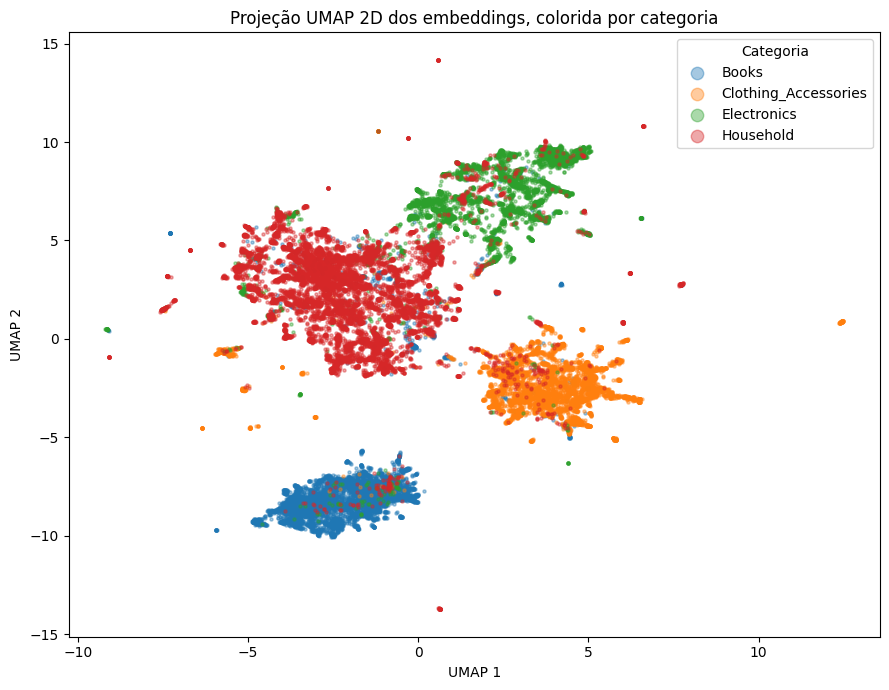

In [11]:
reducer_2d = umap.UMAP(n_components=2, n_jobs=2)
emb_2d = reducer_2d.fit_transform(embeddings)

plt.figure(figsize=(9, 7))
categorias_plot = df['categoria'].values
for cat in sorted(df['categoria'].unique()):
    mask = categorias_plot == cat
    plt.scatter(emb_2d[mask, 0], emb_2d[mask, 1], s=5, alpha=0.4, label=cat)
plt.legend(markerscale=4, title='Categoria')
plt.title('Projeção UMAP 2D dos embeddings, colorida por categoria')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.tight_layout()
plt.savefig('figs/02_umap_2d.png', dpi=100)
plt.show()